In [14]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [15]:
#Load/clean data
df = pd.read_csv('train_set_80_percent.csv')
df = df.drop(columns=["id", "rank", "player", "hard_hit_95mph+"])
df = df.dropna()
df.shape

(1577, 16)

In [16]:
print(df.isnull().sum())

year                                   0
batted_ball_events                     0
launch_angle                           0
sweet_spot_percentage                  0
max_ev                                 0
average_ev                             0
fly_ball_line_drive_ev                 0
ground_ball_ev                         0
max_distance                           0
average_distance                       0
average_homerun                        0
hard_hit_percentage                    0
hard_hit_swing_percentage              0
total_barrels                          0
barrels_batted_balls_percentage        0
barrels_plate_appearance_percentage    0
dtype: int64


In [17]:
#set fixed seed
SEED = 42
np.random.seed(SEED)

#define target variable
target_col = "hard_hit_percentage"
X = df.drop(columns=[target_col])
y = df[target_col]

In [18]:
#5-fold Cross-validation and evaluation metrics(R², MSE)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "neg_mse": "neg_mean_squared_error"
}

In [19]:
#Base Linear Regression
lr_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid={},   #no hyperparameters for non-penalized linear regression
    cv=cv,
    scoring=scoring,
    refit="r2"
)

lr_grid.fit(X, y)

lr_cv_r2 = lr_grid.best_score_
lr_cv_mse = -lr_grid.cv_results_["mean_test_neg_mse"][0]

print("Linear Regression:CV R²:", lr_cv_r2)
print("Linear Regression:CV MSE:", lr_cv_mse)


Linear Regression:CV R²: 0.9416932350506304
Linear Regression:CV MSE: 3.631811610804532


In [20]:
#Ridge Regression
ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 500]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring=scoring,
    refit="r2",
    n_jobs=-1
)

ridge_grid.fit(X, y)

ridge_cv_r2 = ridge_grid.best_score_
ridge_cv_mse = -ridge_grid.cv_results_["mean_test_neg_mse"][ridge_grid.best_index_]

print("Ridge BEST PARAMS:", ridge_grid.best_params_)
print("Ridge:CV R²:", ridge_cv_r2)
print("Ridge:CV MSE:", ridge_cv_mse)

Ridge BEST PARAMS: {'model__alpha': 1}
Ridge:CV R²: 0.9416977708860614
Ridge:CV MSE: 3.6315432687813236


In [21]:
#Lasso Regression
lasso_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", Lasso(max_iter=10000, random_state=SEED))
])

lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    cv=cv,
    scoring=scoring,
    refit="r2",
    n_jobs=-1
)

lasso_grid.fit(X, y)

lasso_cv_r2 = lasso_grid.best_score_
lasso_cv_mse = -lasso_grid.cv_results_["mean_test_neg_mse"][lasso_grid.best_index_]

print("Lasso Best Params:", lasso_grid.best_params_)
print("Lasso:CV R²:", lasso_cv_r2)
print("Lasso:CV MSE:", lasso_cv_mse)

Lasso Best Params: {'model__alpha': 0.001}
Lasso:CV R²: 0.9416955656679526
Lasso:CV MSE: 3.6316303445264473


In [22]:
#ElasticNet Regression
elastic_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=SEED))
])

elastic_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    estimator=elastic_pipe,
    param_grid=elastic_param_grid,
    cv=cv,
    scoring=scoring,
    refit="r2",
    n_jobs=-1
)

elastic_grid.fit(X, y)

elastic_cv_r2 = elastic_grid.best_score_
elastic_cv_mse = -elastic_grid.cv_results_["mean_test_neg_mse"][elastic_grid.best_index_]

print("ElasticNet BEST PARAMS:", elastic_grid.best_params_)
print("ElasticNet:CV R²:", elastic_cv_r2)
print("ElasticNet:CV MSE:", elastic_cv_mse)

ElasticNet BEST PARAMS: {'model__alpha': 0.001, 'model__l1_ratio': 0.5}
ElasticNet:CV R²: 0.9416971866445432
ElasticNet:CV MSE: 3.631557552797969


In [23]:
#summary table
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "ElasticNet"],
    "CV_R2": [lr_cv_r2, ridge_cv_r2, lasso_cv_r2, elastic_cv_r2],
    "CV_MSE": [lr_cv_mse, ridge_cv_mse, lasso_cv_mse, elastic_cv_mse]
})

results


,Model,CV_R2,CV_MSE
0,Linear,0.941693,3.631812
1,Ridge,0.941698,3.631543
2,Lasso,0.941696,3.631630
3,ElasticNet,0.941697,3.631558


In [24]:
#compare models for the best one (ridge, lasso, or elastic)
best_model_name = results.loc[results["CV_R2"].idxmax(), "Model"]
print("Best model based on CV R²:", best_model_name)

if best_model_name == "Linear":
    best_model = lr_grid.best_estimator_
elif best_model_name == "Ridge":
    best_model = ridge_grid.best_estimator_
elif best_model_name == "Lasso":
    best_model = lasso_grid.best_estimator_
else:
    best_model = elastic_grid.best_estimator_


Best model based on CV R²: Ridge


In [25]:
y_pred = best_model.predict(X)

print("Training R²:", r2_score(y, y_pred))
print("Training MSE:", mean_squared_error(y, y_pred))


Training R²: 0.9436835712078304
Training MSE: 3.526509551717176


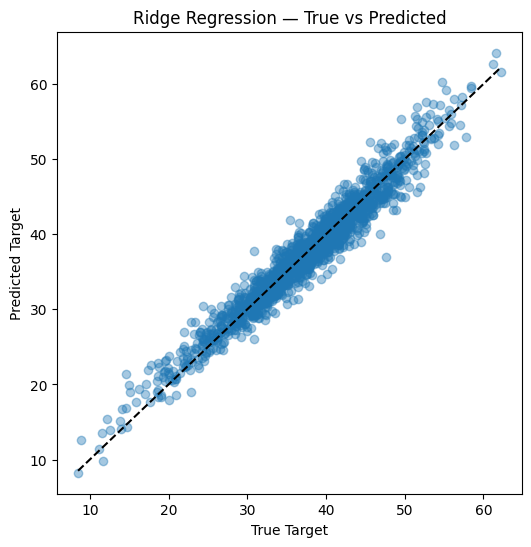

In [26]:
#plot Ridge Regression
plt.figure(figsize=(6,6))
plt.scatter(x=y, y=y_pred, alpha=0.4)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title(f"{best_model_name} Regression — True vs Predicted")
plt.plot([min(y), max(y)], [min(y), max(y)], "k--")
plt.show()
